In [1]:
#Importamos las librerias necesarias para el análisis de datos y visualización
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import libpysal


In [2]:
#Cargamos el archivo shapefile de las ocurrencias minerales con el que desarrollaremos el análisis geoespacial.
OcurrenciasMinerales = gpd.read_file("C:\\Users\\USUARIO\\Documents\\ESPECIALIZACION_GNM\\ANALISIS_GEOESPACIAL\\AnalisisGeoespacial_2026\\Ocurrencias_A-T.shp")
OcurrenciasMinerales.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2179 entries, 0 to 2178
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    2179 non-null   int64   
 1   SOURCE      2179 non-null   str     
 2   X_Este      2179 non-null   float64 
 3   Y_Norte     2179 non-null   float64 
 4   MINERAL_PP  2179 non-null   str     
 5   FORMA_OCUR  2179 non-null   str     
 6   ID_NOM_DEP  2057 non-null   str     
 7   IG_MUN      2179 non-null   str     
 8   IG_DEP      2179 non-null   str     
 9   geometry    2179 non-null   geometry
dtypes: float64(2), geometry(1), int64(1), str(6)
memory usage: 170.4 KB


In [3]:
OcurrenciasMinerales.head(5)


,OBJECTID,SOURCE,X_Este,Y_Norte,MINERAL_PP,FORMA_OCUR,ID_NOM_DEP,IG_MUN,IG_DEP,geometry
0,1,SGC,841888.193,1139745.879,Calizas,Estratiforme,Cementos El Cairo S.A.,Abejorral,Antioquia,POINT (841888.193 1139745.879)
1,2,SGC,851442.791,1132864.149,Arcilla_Caolinita,Estratiforme,El Gallinazo,Abejorral,Antioquia,POINT (851442.791 1132864.149)
2,3,SGC,851622.602,1133947.763,Oro-Au,Veta,El Popal,Abejorral,Antioquia,POINT (851622.602 1133947.763)
3,4,SGC,859862.897,1138087.896,Oro-Au,Veta,El Rebusque,Abejorral,Antioquia,POINT (859862.897 1138087.896)
4,5,SGC,845435.507,1136274.605,Arcilla_Caolinita,Estratiforme,EUROCERAMICA S.A.,Abejorral,Antioquia,POINT (845435.507 1136274.605)


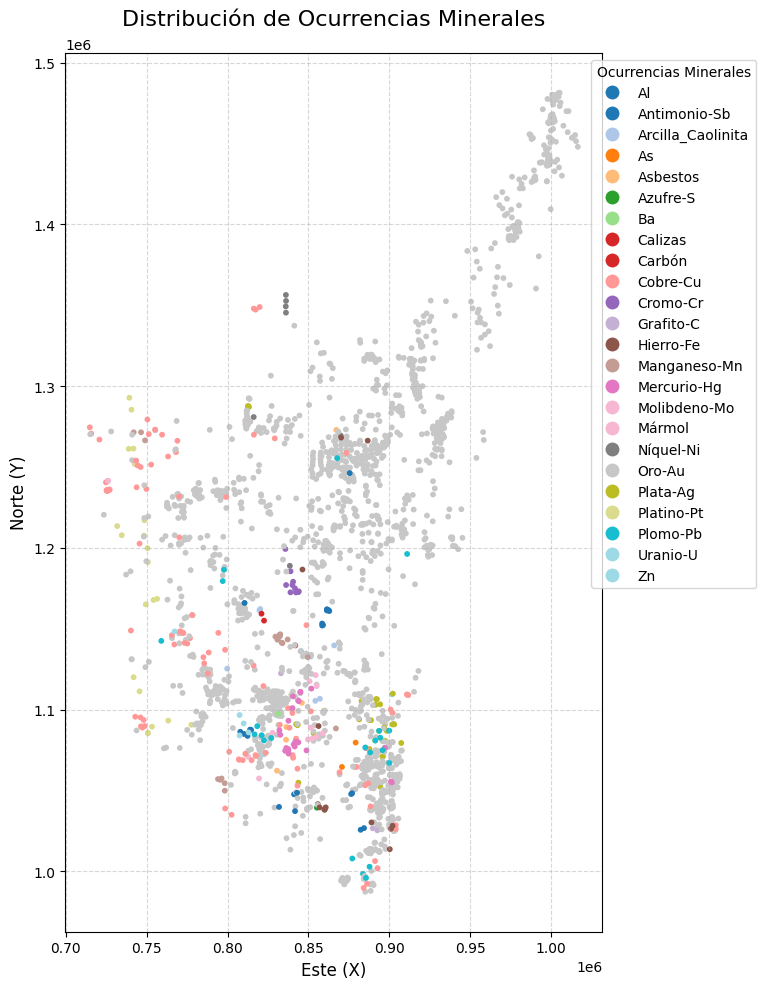

In [4]:
#Vamos a gráficar los puntos categorizados por el tipo de mineral.
fig, ax = plt.subplots(figsize=(10, 10))
OcurrenciasMinerales.plot(
    column="MINERAL_PP",  # Columna para categorizar los puntos
    categorical=True,
    legend=True,
    cmap="tab20",  # Colormap para diferenciar categorías
    markersize=10,
    ax=ax,
    legend_kwds={
        'title': "Ocurrencias Minerales",  # Título de la leyenda
        'loc': 'upper right',    # Ubicación de la leyenda
        'bbox_to_anchor': (1.3, 1) # Mueve la leyenda fuera del mapa si es muy grande
    }
)
#Personalizar el diseño del mapa
ax.set_title('Distribución de Ocurrencias Minerales', fontsize=16, pad=20)
ax.set_xlabel('Este (X)', fontsize=12)
ax.set_ylabel('Norte (Y)', fontsize=12)

#Activar una cuadrícula de fondo
ax.grid(True, linestyle='--', alpha=0.5)

#Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()

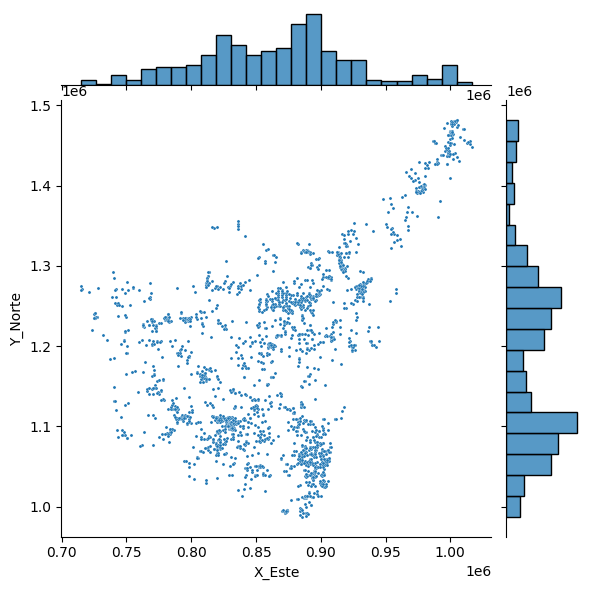

In [5]:
# Generar scatter plot
import seaborn as sbn
sbn.jointplot(x='X_Este', y='Y_Norte', data=OcurrenciasMinerales, s=5)

In [6]:
#Cargamos el archivo shapefile de la geología y las fallas de la zona de trabajo.
Geologia = gpd.read_file("C:\\Users\\USUARIO\\Documents\\ESPECIALIZACION_GNM\\ANALISIS_GEOESPACIAL\\AnalisisGeoespacial_2026\\Geologia_A-T.shp")
Fallas = gpd.read_file("C:\\Users\\USUARIO\\Documents\\ESPECIALIZACION_GNM\\ANALISIS_GEOESPACIAL\\AnalisisGeoespacial_2026\\Fallas_A-T.shp")

#Tabla de atributos de la geología
Geologia.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1750 entries, 0 to 1749
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    1750 non-null   int32   
 1   SimboloUC   1750 non-null   str     
 2   N°CartaCo   0 non-null      object  
 3   Descripcio  1750 non-null   str     
 4   Edad        1750 non-null   str     
 5   UGIntegrad  696 non-null    str     
 6   Comentario  2 non-null      str     
 7   GlobalID    1750 non-null   str     
 8   Shape__Are  1750 non-null   float64 
 9   Shape__Len  1750 non-null   float64 
 10  MINX        1750 non-null   float64 
 11  MINY        1750 non-null   float64 
 12  MAXX        1750 non-null   float64 
 13  MAXY        1750 non-null   float64 
 14  CNTX        1750 non-null   float64 
 15  CNTY        1750 non-null   float64 
 16  AREA        1750 non-null   float64 
 17  PERIM       1750 non-null   float64 
 18  HEIGHT      1750 non-null   float64 
 19

<Axes: >

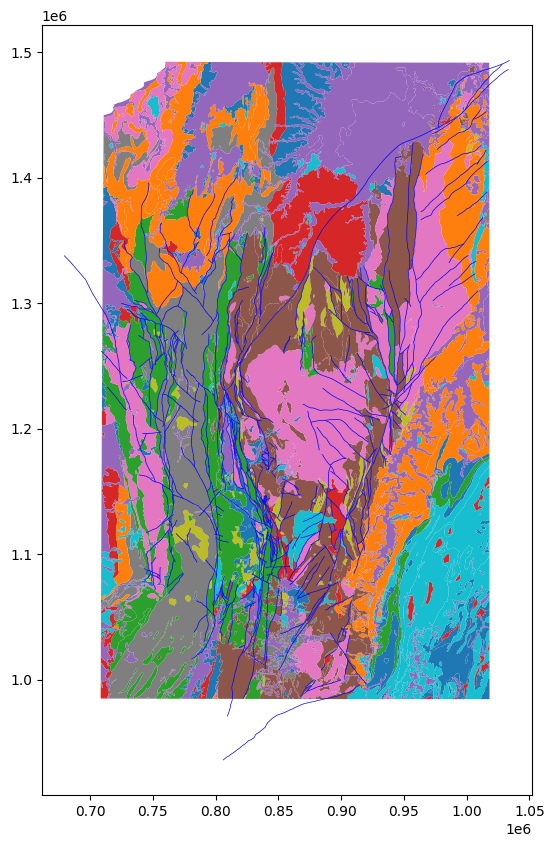

In [7]:
Fallas.plot(ax=Geologia.plot(column="Descripcio", categorical=True, figsize=(10, 10)), color='blue',linewidth=0.5)



In [8]:
#Verificamos el sistema de referencia de cada capa. Todas deben estar en EPSG:21897 para que las medidas de distancia (fallas, KDE, vecinos) sean válidas.
CRS_PROYECTO = "EPSG:21897"
for nombre, capa in [("Ocurrencias", OcurrenciasMinerales), ("Geologia", Geologia), ("Fallas", Fallas)]:
    print(nombre, "->", capa.crs)

Ocurrencias -> EPSG:21897
Geologia -> EPSG:21897
Fallas -> EPSG:21897


In [9]:
#Filtramos la base de datos por Oro (Au), foco del proyecto.
col_mineral = "MINERAL_PP"
OcurrenciasAu = OcurrenciasMinerales[
    OcurrenciasMinerales[col_mineral].str.contains("Oro", case=False, na=False)
].copy()
print("Ocurrencias de Au:", len(OcurrenciasAu))

Ocurrencias de Au: 1835


In [10]:

#Construimos el Área de Trabajo como un alpha shape a partir de la BD de Ocurrencias.
coords = np.array([(p.x, p.y) for p in OcurrenciasMinerales.geometry])

alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(coords, return_circles=True)

AreaTrabajo = gpd.GeoDataFrame(geometry=[alpha_shape], crs=CRS_PROYECTO)
print("Área de Trabajo (alpha shape):", round(AreaTrabajo.area.iloc[0] / 1e6, 1), "km²")



Área de Trabajo (alpha shape): 59196.6 km²


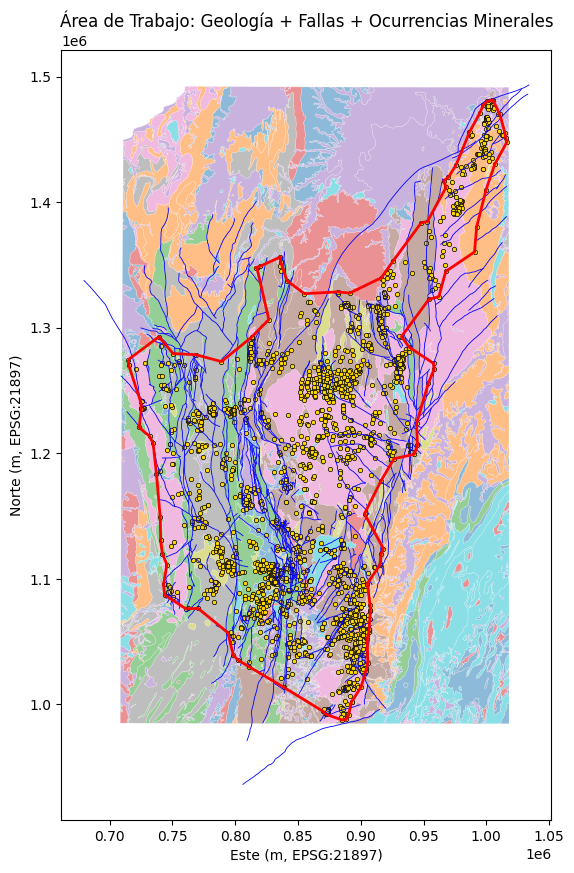

In [11]:
#Gráficamos los 4 elementos que tenemos hasta ahora (BD, Geologia, Fallas, AreaTrabajo (Alpha Shape)).
fig, ax = plt.subplots(figsize=(10, 10))
Geologia.plot(ax=ax,column="Descripcio", categorical=True, edgecolor="white", linewidth=0.3, alpha=0.5)
Fallas.plot(ax=ax, color="blue", linewidth=0.6)
OcurrenciasMinerales.plot(ax=ax, markersize=10, color="gold", edgecolor="k", linewidth=0.5)
AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=2)
ax.set_title("Área de Trabajo: Geología + Fallas + Ocurrencias Minerales")
ax.set_xlabel("Este (m, EPSG:21897)"); ax.set_ylabel("Norte (m, EPSG:21897)")
plt.show()

In [12]:
#Realizamos analisis de centrografía para describir la forma y orientación de la distribución espacial de las ocurrencias minerales.

from pointpats import centrography
from matplotlib.patches import Ellipse, Circle

#Extraemos las coordenadas (x, y) de las ocurrencias de Au como array de NumPy.
CoordsAu = np.array([(p.x, p.y) for p in OcurrenciasAu.geometry])

#Centro medio: el "promedio" espacial de los 384 puntos.
CentroMedio = centrography.mean_center(CoordsAu)

#Distancia estándar: dispersión radial (un radio en metros).
DistStd = centrography.std_distance(CoordsAu)

#Elipse de desviación estándar: semiejes y ángulo de rotación.
SemiMayor, SemiMenor, Rotacion = centrography.ellipse(CoordsAu)

print("Centro medio (x, y):",np.round(CentroMedio, 1))
print("Distancia estándar:", round(DistStd, 0), "m  (~", round(DistStd/1000, 1), "km )")
print("Semiejes elipse:", round(SemiMayor,0), "x", round(SemiMenor,0), "m")
print("Rotación (grados):", round(np.degrees(Rotacion), 1))

Centro medio (x, y): [ 872970.2 1193332.9]
Distancia estándar: 131501.0 m  (~ 131.5 km )
Semiejes elipse: 173148.0 x 68135.0 m
Rotación (grados): 72.8


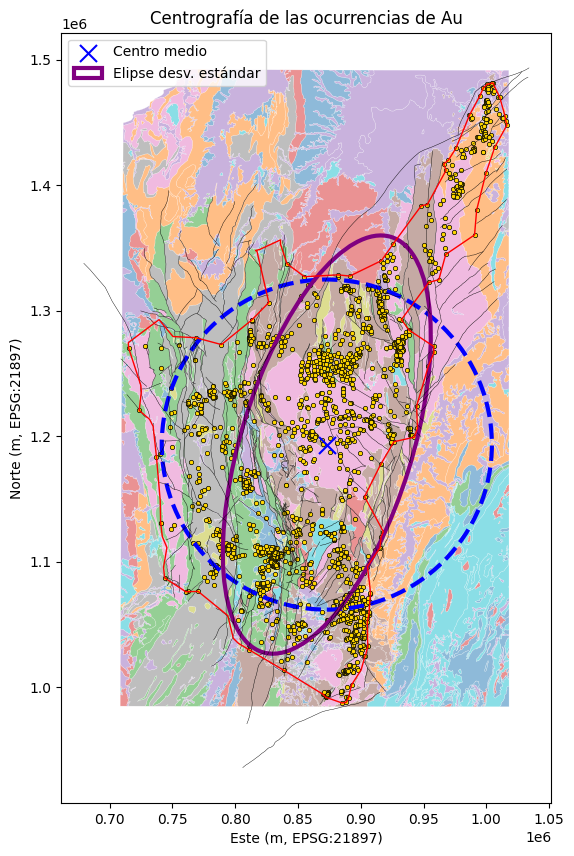

In [13]:
#Visualizamos la centrografía sobre el Área de Trabajo para interpretar la forma y orientación de la distribución de las ocurrencias de Au.
fig, ax = plt.subplots(figsize=(10, 10))
Geologia.plot(ax=ax,column="Descripcio", categorical=True, edgecolor="white", linewidth=0.3, alpha=0.5)
Fallas.plot(ax=ax, color="black", linewidth=0.3)
OcurrenciasAu.plot(ax=ax, markersize=10, color="gold", edgecolor="k", linewidth=0.5)
AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=1)

#Centro medio
ax.scatter(*CentroMedio, color="blue", marker="x", s=150, zorder=5, label="Centro medio")

#Círculo de distancia estándar
ax.add_patch(Circle(CentroMedio, radius=DistStd, edgecolor="blue",
                    facecolor="none", linestyle="--", linewidth=3))

#Elipse de desviación estándar
elipse = Ellipse(xy=CentroMedio, width=2*SemiMayor, height=2*SemiMenor,
                 angle=np.degrees(Rotacion), edgecolor="purple",
                 facecolor="none", linewidth=3, label="Elipse desv. estándar")
ax.add_patch(elipse)

ax.set_title("Centrografía de las ocurrencias de Au")
ax.set_xlabel("Este (m, EPSG:21897)"); ax.set_ylabel("Norte (m, EPSG:21897)")
ax.legend(); plt.show()

<Figure size 1200x1600 with 0 Axes>

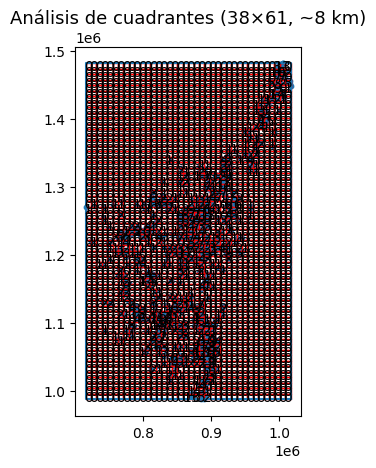

Chi²: 21182.0
Grados de libertad: 2317
p-valor: 0.0


In [14]:
# Análisis de Cuadrantes
import matplotlib.pyplot as plt
from pointpats import QStatistic

QAu = QStatistic(CoordsAu, shape="rectangle", nx=38, ny=61)

plt.figure(figsize=(12, 16))

QAu.plot()                      

plt.title("Análisis de cuadrantes (38×61, ~8 km)", fontsize=13)
plt.savefig("Cuadrantes_Au.png", dpi=300, bbox_inches="tight")
plt.show()

print("Chi²:", round(QAu.chi2, 1))
print("Grados de libertad:", QAu.df)
print("p-valor:", QAu.chi2_pvalue)

In [15]:
print([a for a in dir(QAu) if not a.startswith("_")])

['cell_ids', 'chi2', 'chi2_contrib', 'chi2_pvalue', 'df', 'mbb', 'mr', 'plot', 'points', 'rng', 'shape', 'window']


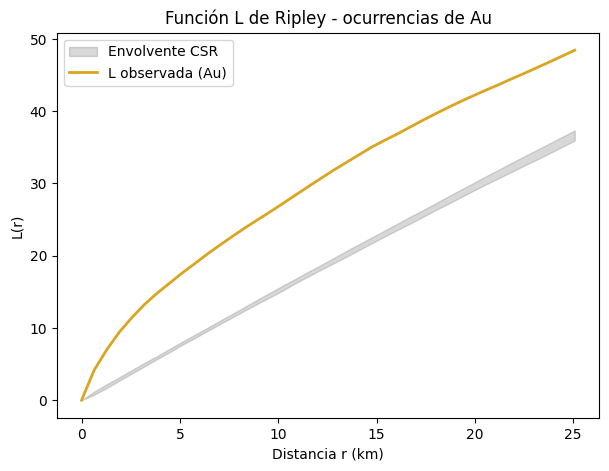

In [16]:
from pointpats import l_test

#Realizamos analisis de K de Ripley para evaluar la presencia de patrones de agrupamiento o dispersión a diferentes escalas espaciales.

Ventana = AreaTrabajo.geometry.iloc[0]   #polígono shapely

ResultL = l_test(
    CoordsAu,
    support=40,             #número de radios r a evaluar
    n_simulations=199,      #199 simulaciones -> banda ~99%
    keep_simulations=True,
    hull=Ventana,           #ventana real para generar el CSR
)

r   = ResultL.support
obs = ResultL.statistic
sims = ResultL.simulations
lo, hi = sims.min(axis=0), sims.max(axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(r/1000, lo/1000, hi/1000, color="grey", alpha=0.3, label="Envolvente CSR")
ax.plot(r/1000, obs/1000, color="goldenrod", lw=2, label="L observada (Au)")
ax.set_xlabel("Distancia r (km)"); ax.set_ylabel("L(r)")
ax.legend(); ax.set_title("Función L de Ripley - ocurrencias de Au")
plt.show()

Escala de máximo exceso de agrupamiento: 14.8 km


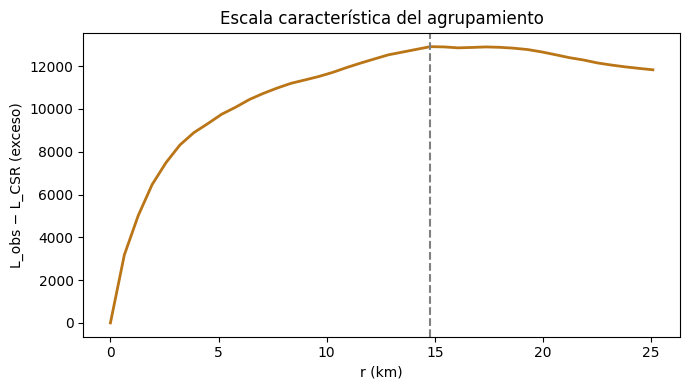

In [17]:
import numpy as np, matplotlib.pyplot as plt

r      = np.asarray(ResultL.support)
Lobs   = np.asarray(ResultL.statistic)
sims   = np.asarray(ResultL.simulations)
csr    = sims.mean(axis=0)
exceso = Lobs - csr

r_peak = r[np.argmax(exceso)]
print("Escala de máximo exceso de agrupamiento:", round(r_peak/1000, 1), "km")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(r/1000, exceso, color="#BA7517", lw=2)
ax.axvline(r_peak/1000, ls="--", color="gray")
ax.set_xlabel("r (km)"); ax.set_ylabel("L_obs − L_CSR (exceso)")
ax.set_title("Escala característica del agrupamiento")
plt.tight_layout(); plt.show()

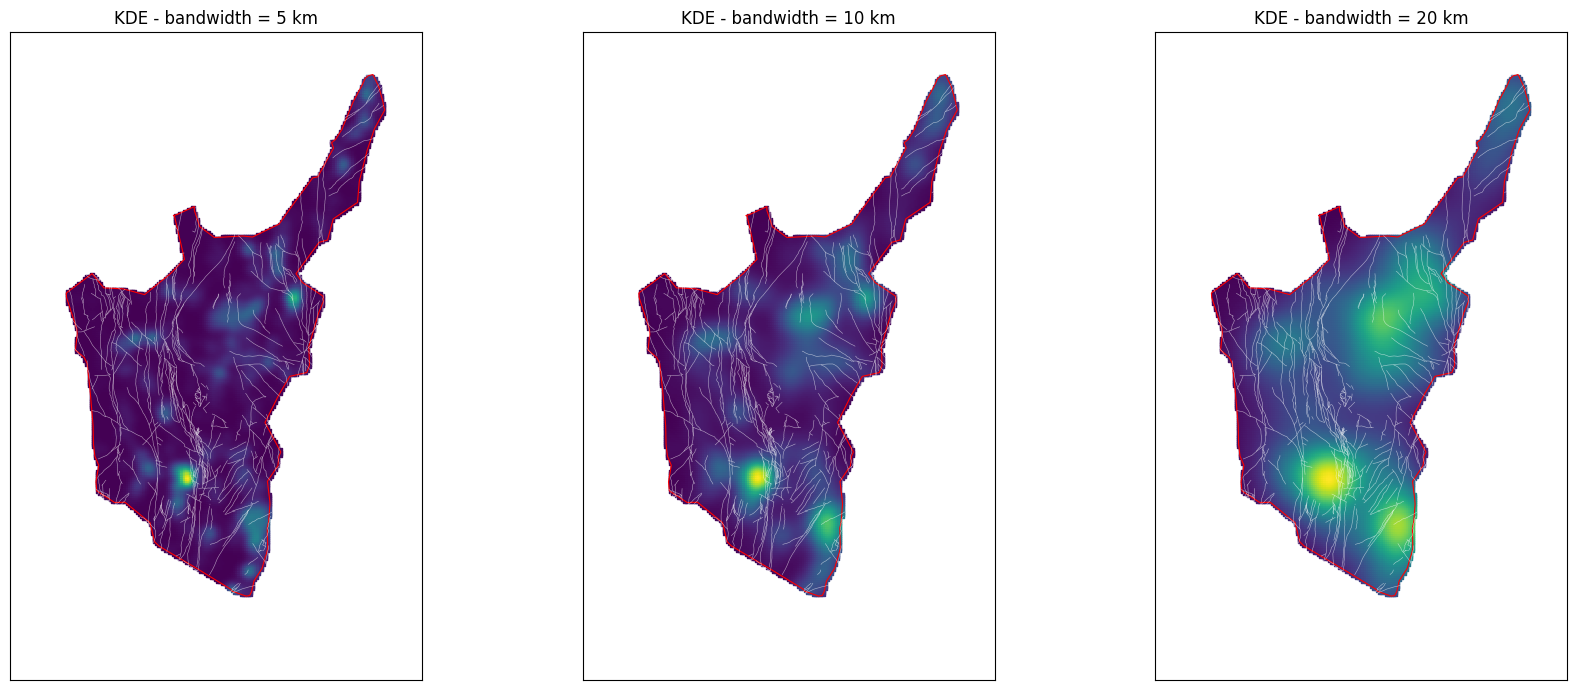

In [18]:
from sklearn.neighbors import KernelDensity
#Construimos una grilla de evaluación que cubra el Área de Trabajo.
#   Resolución de 2 km (2000 m)
xmin, ymin, xmax, ymax = AreaTrabajo.total_bounds
res = 2000
xx, yy = np.meshgrid(
    np.arange(xmin, xmax, res),
    np.arange(ymin, ymax, res),
)
grid_coords = np.column_stack([xx.ravel(), yy.ravel()])

#Recortamos la grilla al alpha shape (solo evaluamos dentro de la ventana).
grid_pts = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(grid_coords[:,0], grid_coords[:,1]),
    crs=CRS_PROYECTO,
)
dentro = grid_pts.within(AreaTrabajo.geometry.iloc[0])
grid_in = grid_coords[dentro.values]

#Ajustamos el KDE. El bandwidth está en METROS
#   Probamos tres anchos guiados por la escala de Ripley.
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, bw in zip(axes, [5000, 10000, 20000]):   #5, 10 y 20 km
    kde = KernelDensity(bandwidth=bw, kernel="gaussian")
    kde.fit(CoordsAu)
    #log-densidad -> densidad
    dens = np.exp(kde.score_samples(grid_in))

    sc = ax.scatter(grid_in[:,0], grid_in[:,1], c=dens, cmap="viridis", s=8, marker="s")
    AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=0.8)
    Fallas.plot(ax=ax, color="white", linewidth=0.4, alpha=0.6)
    ax.set_title(f"KDE - bandwidth = {bw/1000:.0f} km")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [19]:
#Vamos a construir una retícula de celdas cuadradas de 5 km de lado para realizar análisis de vecinos y autocorrelación espacial.

from shapely.geometry import box

#Tamaño de celda: 5 km. (escala de agrupamiento dominante que estimó la K de Ripley)
cell = 5000
xmin, ymin, xmax, ymax = AreaTrabajo.total_bounds

celdas = []
x = xmin
while x < xmax:
    y = ymin
    while y < ymax:
        celdas.append(box(x, y, x + cell, y + cell))
        y += cell
    x += cell

Reticula = gpd.GeoDataFrame(geometry=celdas, crs=CRS_PROYECTO)

#Conservamos solo las celdas que intersectan el Área de Trabajo (alpha shape).
Reticula = Reticula[Reticula.intersects(AreaTrabajo.geometry.iloc[0])].reset_index(drop=True)
Reticula["cell_id"] = Reticula.index
print("Celdas en la retícula:", len(Reticula))

Celdas en la retícula: 2548


In [20]:
#Conteo de ocurrencias de Au por celda mediante unión espacial.
join = gpd.sjoin(OcurrenciasAu, Reticula, how="left", predicate="within")
conteo = join.groupby("cell_id").size()
Reticula["n_au"] = Reticula["cell_id"].map(conteo).fillna(0).astype(int)

print("Total Au repartido en la retícula:", Reticula["n_au"].sum())   # debe dar 384
print(Reticula["n_au"].describe())

Total Au repartido en la retícula: 1834
count    2548.000000
mean        0.719780
std         1.888107
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        27.000000
Name: n_au, dtype: float64


In [21]:
#Vamos a construir la matriz W de pesos espaciales basada en la contigüidad de las celdas (vecinos por Queen).

from libpysal.weights import Queen, KNN, lag_spatial

#Contigüidad Reina sobre la retícula.
W_Reina = Queen.from_dataframe(Reticula, use_index=False)
W_Reina.transform = "r"   # estandarización por filas

print("Celdas:", len(Reticula))
print("Islas (celdas sin vecinos):", W_Reina.islands)   # <- revisar esto
print("Promedio de vecinos por celda:", round(W_Reina.mean_neighbors, 2))

Celdas: 2548
Islas (celdas sin vecinos): []
Promedio de vecinos por celda: 7.66


In [22]:
#Si W_Reina.islands NO está vacío, usa KNN para garantizar vecinos:
W_KNN = KNN.from_dataframe(Reticula, k=8)
W_KNN.transform = "r"
print("Islas con KNN:", W_KNN.islands)   # debería ser []

Islas con KNN: []


In [23]:
#El lag espacial de los conteos de Au: el promedio de Au en las celdas vecinas.
W = W_Reina if not W_Reina.islands else W_KNN   # elige según haya islas o no
Reticula["n_au_lag"] = lag_spatial(W, Reticula["n_au"].values)

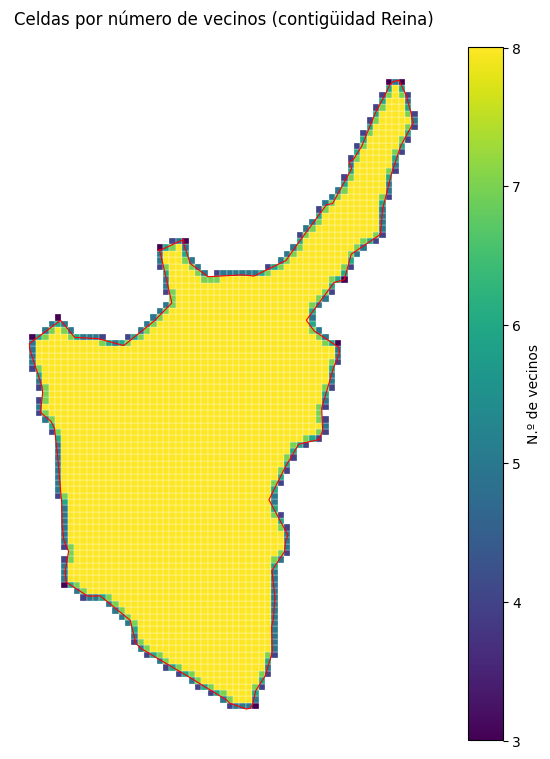

In [24]:
#Celdas coloreadas por número de vecinos.

Reticula["n_vecinos"] = Reticula["cell_id"].map(dict(W_Reina.cardinalities))

fig, ax = plt.subplots(figsize=(8, 9))
Reticula.plot(column="n_vecinos", cmap="viridis", legend=True,
              edgecolor="white", linewidth=0.2, ax=ax,
              legend_kwds={"label": "N.º de vecinos"})
AreaTrabajo.boundary.plot(ax=ax, color="red", linewidth=0.8)
ax.set_title("Celdas por número de vecinos (contigüidad Reina)")
ax.set_axis_off()
plt.show()

In [25]:
from esda.moran import Moran
from splot.esda import plot_moran

y = Reticula["n_au"].values

#W matriz estandarizada por filas.
moran = Moran(y, W_Reina, permutations=999)

print("Moran's I:", round(moran.I, 4))
print("E[I] bajo aleatoriedad:", round(moran.EI, 4))
print("z-score:", round(moran.z_sim, 2))
print("pseudo p-valor:", moran.p_sim)

Moran's I: 0.2972
E[I] bajo aleatoriedad: -0.0004
z-score: 28.88
pseudo p-valor: 0.001


In [26]:
%pip install esda splot

Note: you may need to restart the kernel to use updated packages.


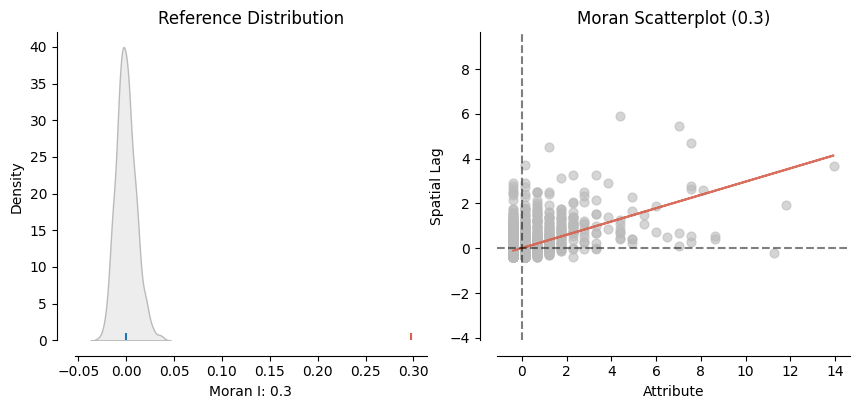

In [27]:
#Gráfico de Moran completo (mapa + scatter + distribución de referencia).
plot_moran(moran, zstandard=True, figsize=(10, 4))
plt.show()

In [28]:
#Vamos a calcular el Moran Local (LISA) para identificar celdas con autocorrelación espacial significativa (hotspots y coldspots).

from esda.moran import Moran_Local
from splot.esda import lisa_cluster, plot_local_autocorrelation

#Moran local: un I por celda, con inferencia por permutaciones.
lisa = Moran_Local(y, W_Reina, permutations=999, seed=42)

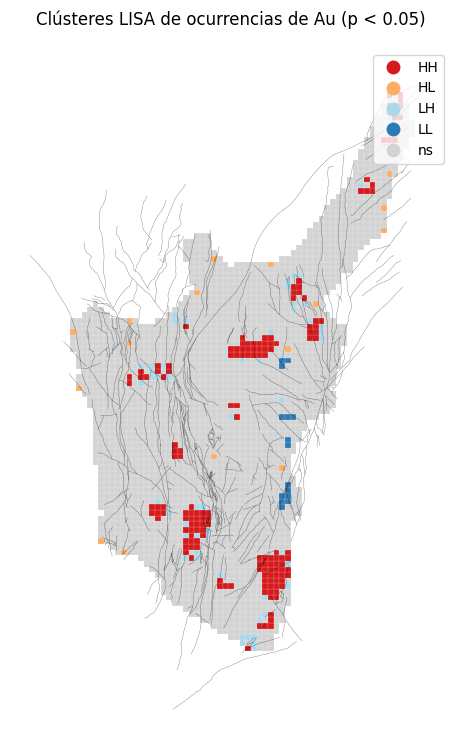

In [29]:
#Mapa de clústeres LISA (solo celdas significativas, coloreadas por cuadrante).
fig, ax = plt.subplots(figsize=(8, 9))
lisa_cluster(lisa, Reticula, p=0.05, ax=ax, legend=True)
Fallas.plot(ax=ax, color="black", linewidth=0.3, alpha=0.5)
ax.set_title("Clústeres LISA de ocurrencias de Au (p < 0.05)")
ax.set_axis_off()
plt.show()

c:\Users\USUARIO\miniconda3\envs\AnalisisGeoespacial_MFCD\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


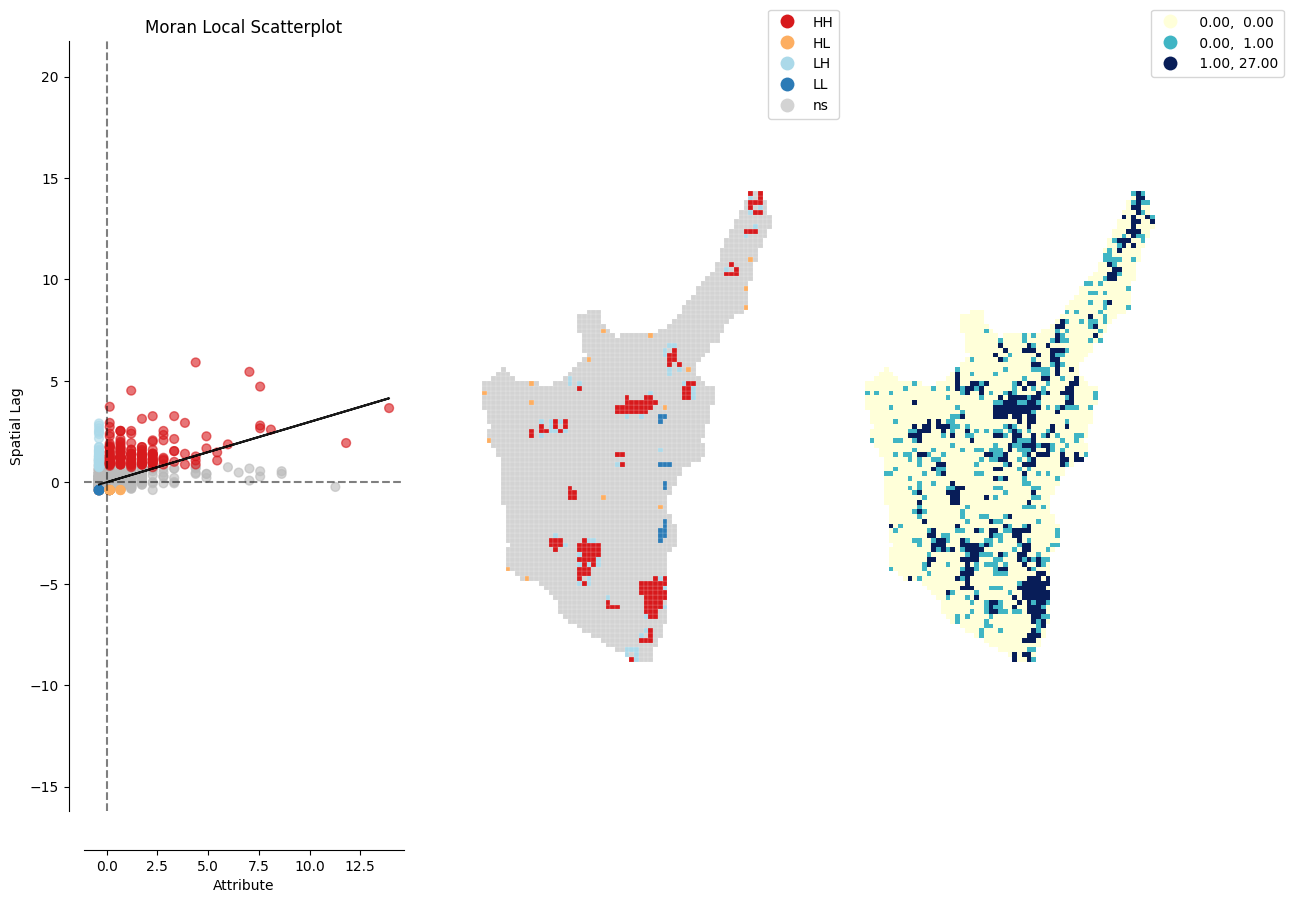

In [30]:
#Vista de 4 paneles: mapa original + scatter de Moran + mapa LISA + significancia.
plot_local_autocorrelation(lisa, Reticula, "n_au", figsize=(14, 10))
plt.show()

In [31]:
#Definición de Covariables de interés para el análisis de regresión espacial.

#Trabajamos sobre la retícula que contienen los conteos de Au (n_au).

#1) Centroides de cada celda: el punto desde donde mediremos la distancia.
centroides = Reticula.geometry.centroid

#2) Unimos todas las fallas en una sola geometría para medir la distancia a la falla mas cercana.
fallas_union = Fallas.union_all()

#3) Distancia de cada centroide a la falla más cercana.
Reticula["dist_fallas"] = centroides.distance(fallas_union)

print(Reticula["dist_fallas"].describe())

count     2548.000000
mean      3406.749454
std       3340.985331
min          0.520232
25%       1013.767161
50%       2361.713322
75%       4750.999601
max      22281.004577
Name: dist_fallas, dtype: float64


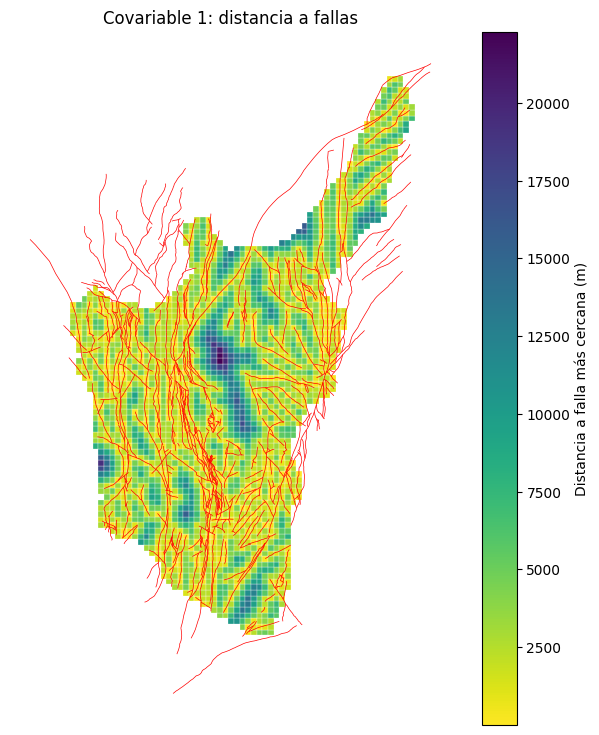

In [32]:
#Visualizamos la covariable para validarla

fig, ax = plt.subplots(figsize=(8, 9))
Reticula.plot(column="dist_fallas", cmap="viridis_r", legend=True, ax=ax,
              edgecolor="white", linewidth=0.2,
              legend_kwds={"label": "Distancia a falla más cercana (m)"})
Fallas.plot(ax=ax, color="red", linewidth=0.5)
ax.set_title("Covariable 1: distancia a fallas")
ax.set_axis_off()
plt.show()

In [33]:

#log(d + 1) para manejar el sesgo y evitar log(0) en celdas sobre la falla.
Reticula["log_dist_fallas"] = np.log1p(Reticula["dist_fallas"])
print(Reticula["log_dist_fallas"].describe())

count    2548.000000
mean        7.571431
std         1.250063
min         0.418863
25%         6.922414
50%         7.767566
75%         8.466321
max        10.011535
Name: log_dist_fallas, dtype: float64


In [34]:
#¿Las celdas con más oro tienden a estar más cerca de las fallas?
#Comparamos la distancia media de celdas CON oro vs. SIN oro.
con_oro = Reticula[Reticula["n_au"] > 0]["dist_fallas"]
sin_oro = Reticula[Reticula["n_au"] == 0]["dist_fallas"]

print("Distancia media a falla | celdas CON oro:", round(con_oro.mean(), 0), "m")
print("Distancia media a falla | celdas SIN oro:", round(sin_oro.mean(), 0), "m")

Distancia media a falla | celdas CON oro: 3415.0 m
Distancia media a falla | celdas SIN oro: 3403.0 m


In [35]:
from scipy.stats import spearmanr, mannwhitneyu

#1) Medianas (robustas al sesgo), no medias.
print("Mediana CON oro:", round(con_oro.median(), 0), "m")
print("Mediana SIN oro:", round(sin_oro.median(), 0), "m")

#2) Correlación monótona entre conteo de oro y distancia (Spearman).
rho, p = spearmanr(Reticula["n_au"], Reticula["dist_fallas"])
print(f"Spearman n_au vs dist_fallas: rho={rho:.3f}, p={p:.3f}")

#3) ¿Difieren las distribuciones? (Mann-Whitney, no asume normalidad)
u, p_mw = mannwhitneyu(con_oro, sin_oro, alternative="two-sided")
print(f"Mann-Whitney (con vs sin oro): p={p_mw:.3f}")


Mediana CON oro: 2361.0 m
Mediana SIN oro: 2362.0 m
Spearman n_au vs dist_fallas: rho=0.011, p=0.576
Mann-Whitney (con vs sin oro): p=0.743


In [36]:
#Densidad de fallas: longitud total de falla dentro de cada celda / área de la celda.

fallas_en_celda = gpd.overlay(Fallas, Reticula[["cell_id", "geometry"]], how="intersection")
fallas_en_celda["long_m"] = fallas_en_celda.geometry.length
long_por_celda = fallas_en_celda.groupby("cell_id")["long_m"].sum()

area_celda_km2 = (10000 * 10000) / 1e6          # 100 km² por celda de 10 km
Reticula["dens_fallas"] = (Reticula["cell_id"].map(long_por_celda).fillna(0) / 1000) / area_celda_km2

#Comparamos densidad media con oro vs. sin oro.
print("Densidad media CON oro:", round(Reticula[Reticula.n_au>0]["dens_fallas"].mean(), 3), "km/km²")
print("Densidad media SIN oro:", round(Reticula[Reticula.n_au==0]["dens_fallas"].mean(), 3), "km/km²")

Densidad media CON oro: 0.035 km/km²
Densidad media SIN oro: 0.037 km/km²


In [37]:
#Clasificación de litología dominante por celda (unión por mayor área).
def clasificar_litologia(desc):
    """Jerarquía: ultramáficas ESTRICTAS primero; luego metamórficas (mandan sobre
    esquistos/anfibolitas con serpentina); luego el resto de máficas (basalto, lava)."""
    d = str(desc).lower()

    # 1) ULTRAMÁFICA ESTRICTA (manda aunque mencione esquisto): roca dominante ultramáfica
    if any(k in d for k in ["dunita","harzburgita","lerzolita","websterita","peridotit"]):
        return "Mafico_Ultramafica"

    # 2) METAMÓRFICA (esquistos, gneises, anfibolitas... aunque listen serpentina/talco)
    if any(k in d for k in ["esquisto","gneis","anfibolita","cuarcita","filita","mármol","marmol",
                            "migmatita","granulita","metatonalita","metagabro","metadiorit",
                            "metalimolit","metareni"]):
        return "Metamorfica"

    # 3) RESTO DE MÁFICAS (volcánicas máficas + serpentinita suelta)
    es_lava_felsica = ("lava" in d and any(f in d for f in ["riolit","dacit","dacít","andesit","andesít"]))
    if any(k in d for k in ["basalto","dolerita","picrita","serpentin","rodingit"]) \
       or ("lava" in d and not es_lava_felsica):
        return "Mafico_Ultramafica"

    # 4) Intrusiva
    if any(k in d for k in ["granodiorit","tonalit","cuarzodiorit","granito","gabro","diorit",
                            "pórfido","porfido","monzonit","granitoide"]):
        return "Intrusiva"

    # 5) Volcánica (félsica-intermedia)
    if any(k in d for k in ["toba","andesít","andesit","volcán","volcan","lapilli","ceniza",
                            "riolit","piroclast","epiclast","dacít","dacit","aglomerado","lava"]):
        return "Volcanica"

    # 6) Cuaternario
    if any(k in d for k in ["aluvial","coluvial","terraza","abanico","paludal","glaciar"]):
        return "Cuaternario"

    # 7) Sedimentaria
    if any(k in d for k in ["arcillolita","arenita","caliza","lodolita","limolita","conglomerado",
                            "turba","carbón","carbon","cuarzoarenita","shale","chert"]):
        return "Sedimentaria"

    return "Otra"

In [38]:
Geologia["litologia"] = Geologia["Descripcio"].apply(clasificar_litologia)
print(Geologia["litologia"].value_counts(dropna=False))
print("Sin clasificar:", (Geologia["litologia"]=="Otra").sum(), "\n")

# Auditoría: la nueva clase NO debe contener esquistos/anfibolitas como roca dominante
print("=== Unidades en Máfico-Ultramáfica (deben ser basaltos/lavas/peridotitas/serpentinitas) ===")
print(Geologia[Geologia.litologia=="Mafico_Ultramafica"]["Descripcio"].drop_duplicates().to_string())

litologia
Cuaternario           476
Sedimentaria          410
Volcanica             257
Metamorfica           236
Intrusiva             225
Mafico_Ultramafica    146
Name: count, dtype: int64
Sin clasificar: 0 

=== Unidades en Máfico-Ultramáfica (deben ser basaltos/lavas/peridotitas/serpentinitas) ===
10      Peridotitas serpentinizadas intruidas por diqu...
21      Basaltos toleíticos, y doleritas, picritas, to...
35      Basaltos, y lodolitas negras intercaladas con ...
57      Basaltos y andesitas basálticas porfiríticas c...
266     Basaltos y andesitas intercalados con arenitas...
321     Intercalaciones de lodolitas calcáreas y silíc...
520     Basaltos; brechas; aglomerados y tobas interca...
557     Harzburgitas, lerzolitas, dunitas y websterita...
987          Dunitas, serpentinitas y esquistos talcosos.
1249                                        Serpentinitas
1453    Basaltos y andesitas asociados con tobas lític...


In [39]:
# Override robusto + verificación en el mismo bloque
mask = Geologia["Descripcio"].str.contains("lodolitas calcáreas y silíceas", case=False, na=False)
print("Filas encontradas:", mask.sum())                       # esperado: 8

Geologia.loc[mask, "litologia"] = "Sedimentaria"              # <-- el cambio

# Verificación inmediata (debe decir Sedimentaria, y ya no Mafico_Ultramafica)
print("Tras override:", Geologia.loc[mask, "litologia"].unique())
print("\nConteo actualizado:")
print(Geologia["litologia"].value_counts())

Filas encontradas: 8
Tras override: <StringArray>
['Sedimentaria']
Length: 1, dtype: str

Conteo actualizado:
litologia
Cuaternario           476
Sedimentaria          418
Volcanica             257
Metamorfica           236
Intrusiva             225
Mafico_Ultramafica    138
Name: count, dtype: int64


In [40]:
print(Geologia["litologia"].value_counts())

litologia
Cuaternario           476
Sedimentaria          418
Volcanica             257
Metamorfica           236
Intrusiva             225
Mafico_Ultramafica    138
Name: count, dtype: int64


In [41]:
# 1) Re-unir a la retícula (la clasificación cambió, hay que rehacer la unión)
Reticula = Reticula.drop(columns=[c for c in ["litologia","lito_grupo"] if c in Reticula.columns])
inter = gpd.overlay(Reticula[["cell_id","geometry"]],
                    Geologia[["litologia","geometry"]], how="intersection")
inter["area_int"] = inter.geometry.area
idx = inter.groupby("cell_id")["area_int"].idxmax()
Reticula = Reticula.merge(inter.loc[idx, ["cell_id","litologia"]], on="cell_id", how="left")

# 2) Agrupar a las 5 clases finales (Sed + Cuaternario -> Sed_Cobertura)
mapa_lito = {
    "Intrusiva":          "Intrusiva",
    "Metamorfica":        "Metamorfica",
    "Mafico_Ultramafica": "Mafico_Ultramafica",
    "Volcanica":          "Volcanica",
    "Sedimentaria":       "Sed_Cobertura",
    "Cuaternario":        "Sed_Cobertura",
}
Reticula["lito_grupo"] = Reticula["litologia"].map(mapa_lito)

# 3) Tabla final de los 5 grupos
print(Reticula.groupby("lito_grupo").agg(
    n_celdas=("n_au","size"),
    celdas_con_oro=("n_au", lambda s:(s>0).sum()),
    oro_total=("n_au","sum"),
).assign(tasa=lambda x:(x.oro_total/x.n_celdas).round(3)).sort_values("tasa", ascending=False))

                    n_celdas  celdas_con_oro  oro_total   tasa
lito_grupo                                                    
Intrusiva                769             258        695  0.904
Metamorfica              766             247        633  0.826
Sed_Cobertura            186              52        118  0.634
Mafico_Ultramafica       379              85        194  0.512
Volcanica                448              96        194  0.433


In [42]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

# Variable binaria (presencia de oro)
Reticula["au_bin"] = (Reticula["n_au"] > 0).astype(int)

# --- GLM 1: Logístico ---
log_mod = smf.logit("au_bin ~ C(lito_grupo, Treatment(reference='Volcanica'))",
                    data=Reticula).fit()
print(log_mod.summary())
print("\nOdds ratios:\n", np.exp(log_mod.params).round(2))

# Test global de la litología (LR) = evidencia "del curso", equivalente a Kruskal-Wallis
log_nulo = smf.logit("au_bin ~ 1", data=Reticula).fit(disp=0)
from scipy.stats import chi2
LR = 2*(log_mod.llf - log_nulo.llf)
print(f"\nTest global litología (logístico): LR={LR:.1f}, gl={int(log_mod.df_model)}, p={chi2.sf(LR, log_mod.df_model):.3g}")

Optimization terminated successfully.
         Current function value: 0.595341
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 au_bin   No. Observations:                 2548
Model:                          Logit   Df Residuals:                     2543
Method:                           MLE   Df Model:                            4
Date:                Fri, 24 Jul 2026   Pseudo R-squ.:                 0.01078
Time:                        20:01:09   Log-Likelihood:                -1516.9
converged:                       True   LL-Null:                       -1533.5
Covariance Type:            nonrobust   LLR p-value:                 1.162e-06
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------

In [43]:
# --- GLM 2: Poisson ---
pois_mod = smf.glm("n_au ~ C(lito_grupo, Treatment(reference='Volcanica'))",
                   data=Reticula, family=sm.families.Poisson()).fit()
print(pois_mod.summary())
print("\nRate ratios (IRR):\n", np.exp(pois_mod.params).round(2))

# Sobredispersión + test global
phi = pois_mod.pearson_chi2 / pois_mod.df_resid
print(f"\nDispersión φ = {phi:.2f}")
pois_nulo = smf.glm("n_au ~ 1", data=Reticula, family=sm.families.Poisson()).fit()
LRp = 2*(pois_mod.llf - pois_nulo.llf)
print(f"Test global litología (Poisson): LR={LRp:.1f}, gl={int(pois_mod.df_model)}, p={chi2.sf(LRp, pois_mod.df_model):.3g}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   n_au   No. Observations:                 2548
Model:                            GLM   Df Residuals:                     2543
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3851.2
Date:                Fri, 24 Jul 2026   Deviance:                       5830.5
Time:                        20:01:09   Pearson chi2:                 1.21e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.05050
Covariance Type:            nonrobust                                         
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [44]:
#Moran sobre los residuos
from esda.moran import Moran

# Residuos del Poisson (el modelo de conteos, base del BYM)
Reticula["resid_pois"] = pois_mod.resid_pearson

# Moran sobre los residuos, con la W de 5 km (W_Reina)
moran_res = Moran(Reticula["resid_pois"].values, W_Reina, permutations=999)
print(f"Moran's I de residuos (Poisson): {moran_res.I:.4f}")
print(f"z-score: {moran_res.z_sim:.2f} | p_sim: {moran_res.p_sim}")

Moran's I de residuos (Poisson): 0.2964
z-score: 29.70 | p_sim: 0.001


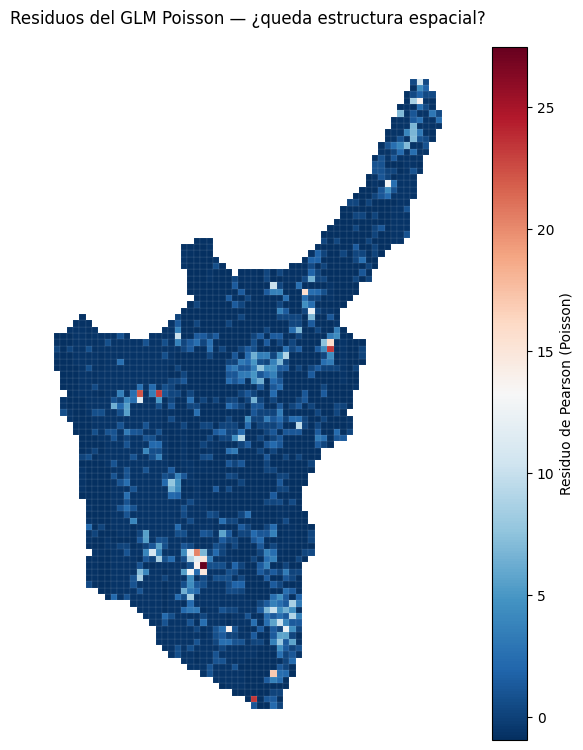

In [45]:
# Visualización: ¿los residuos forman manchones (estructura) o ruido?
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,9))
Reticula.plot(column="resid_pois", cmap="RdBu_r", legend=True, ax=ax,
              edgecolor="white", linewidth=0.05,
              legend_kwds={"label":"Residuo de Pearson (Poisson)"})
ax.set_title("Residuos del GLM Poisson — ¿queda estructura espacial?")
ax.set_axis_off(); plt.show()

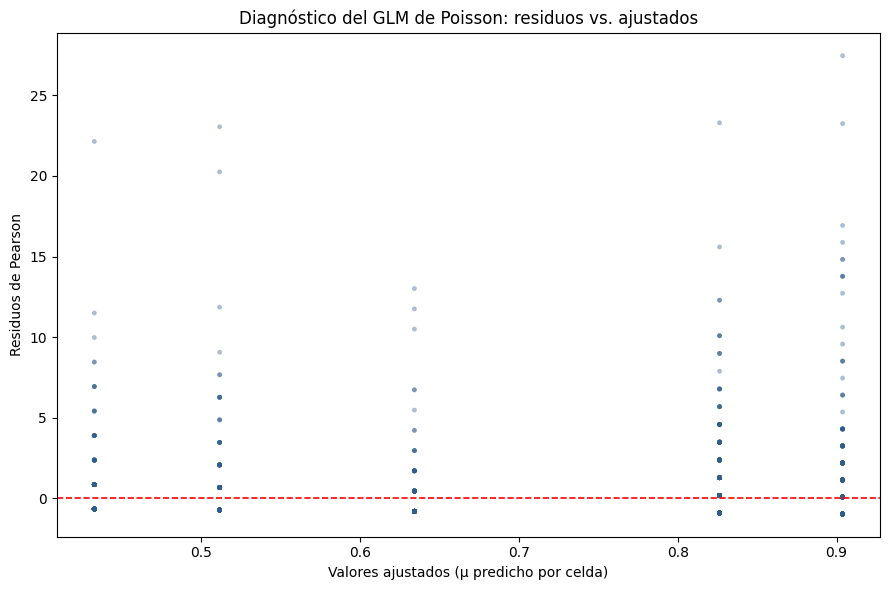

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Valores ajustados y residuos del modelo de Poisson
ajustados = pois_mod.fittedvalues          # lo que el modelo predijo por celda (μ)
resid_pearson = pois_mod.resid_pearson     # residuos de Pearson (estandarizados)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(ajustados, resid_pearson, s=12, alpha=0.4, color="#2E5E8C", edgecolors="none")

# Línea de referencia en 0 (donde el modelo acierta)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)

ax.set_xlabel("Valores ajustados (μ predicho por celda)")
ax.set_ylabel("Residuos de Pearson")
ax.set_title("Diagnóstico del GLM de Poisson: residuos vs. ajustados")
plt.tight_layout()
plt.show()

In [47]:
# Exportar la retícula de 5 km a GeoPackage para R (INLA)
ruta = r"C:\Users\USUARIO\Documents\ESPECIALIZACION_GNM\ANALISIS_GEOESPACIAL\AnalisisGeoespacial_2026\reticula_bym.gpkg"

# Nos aseguramos de exportar solo lo necesario, con cell_id para mantener el orden
cols_exportar = ["cell_id", "n_au", "lito_grupo", "geometry"]
Reticula[cols_exportar].to_file(ruta, driver="GPKG")

print("Exportado a:", ruta)
print("Celdas:", len(Reticula), "| columnas:", cols_exportar)

Exportado a: C:\Users\USUARIO\Documents\ESPECIALIZACION_GNM\ANALISIS_GEOESPACIAL\AnalisisGeoespacial_2026\reticula_bym.gpkg
Celdas: 2548 | columnas: ['cell_id', 'n_au', 'lito_grupo', 'geometry']


In [48]:
from matplotlib.colors import LogNorm

# 1) Cargar la malla de resultados que generó R
ruta = r"C:\Users\USUARIO\Documents\ESPECIALIZACION_GNM\ANALISIS_GEOESPACIAL\AnalisisGeoespacial_2026\reticula_bym_resultados.gpkg"
malla = gpd.read_file(ruta)

# Ver qué columnas trae (para confirmar los nombres)
print(malla.columns.tolist())
print(malla[["n_au", "prospectividad", "efecto_espacial"]].describe())

['cell_id', 'n_au', 'lito_grupo', 'idx', 'efecto_espacial', 'prospectividad', 'geometry']
              n_au  prospectividad  efecto_espacial
count  2548.000000     2548.000000      2548.000000
mean      0.719780        0.783219         0.003441
std       1.888107        1.646023         1.483345
min       0.000000        0.001850        -5.993126
25%       0.000000        0.137471        -0.917071
50%       0.000000        0.291175        -0.077339
75%       1.000000        0.692548         0.868356
max      27.000000       26.022939         4.684044


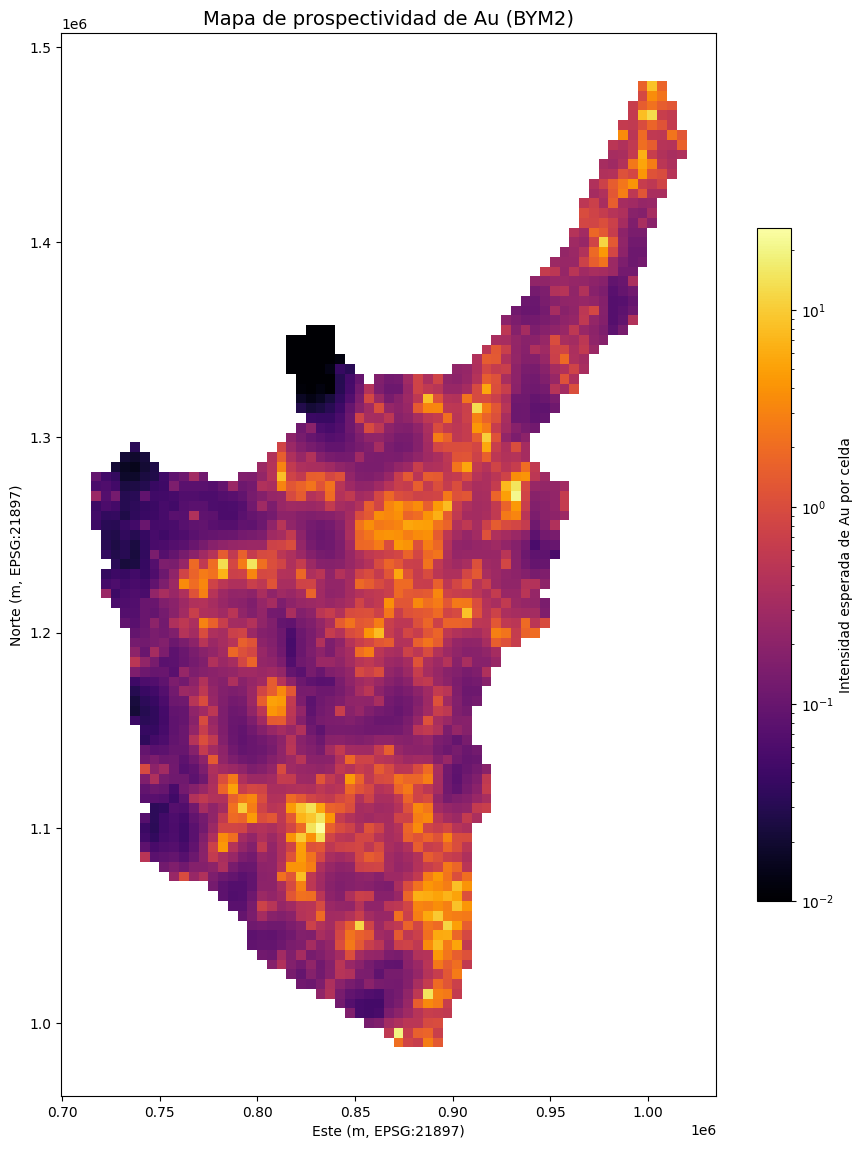

In [49]:
# 2) Mapa de prospectividad (intensidad esperada, escala log para ver el gradiente)
fig, ax = plt.subplots(figsize=(9, 12))

malla.plot(column="prospectividad",
           cmap="inferno",
           norm=LogNorm(vmin=max(malla["prospectividad"].min(), 0.01),
                        vmax=malla["prospectividad"].max()),
           legend=True,
           legend_kwds={"label": "Intensidad esperada de Au por celda",
                        "shrink": 0.6},
           ax=ax, edgecolor="none")

ax.set_title("Mapa de prospectividad de Au (BYM2)", fontsize=14)
ax.set_xlabel("Este (m, EPSG:21897)")
ax.set_ylabel("Norte (m, EPSG:21897)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("MapaProspectividad_BYM2_python.png", dpi=300, bbox_inches="tight")
plt.show()

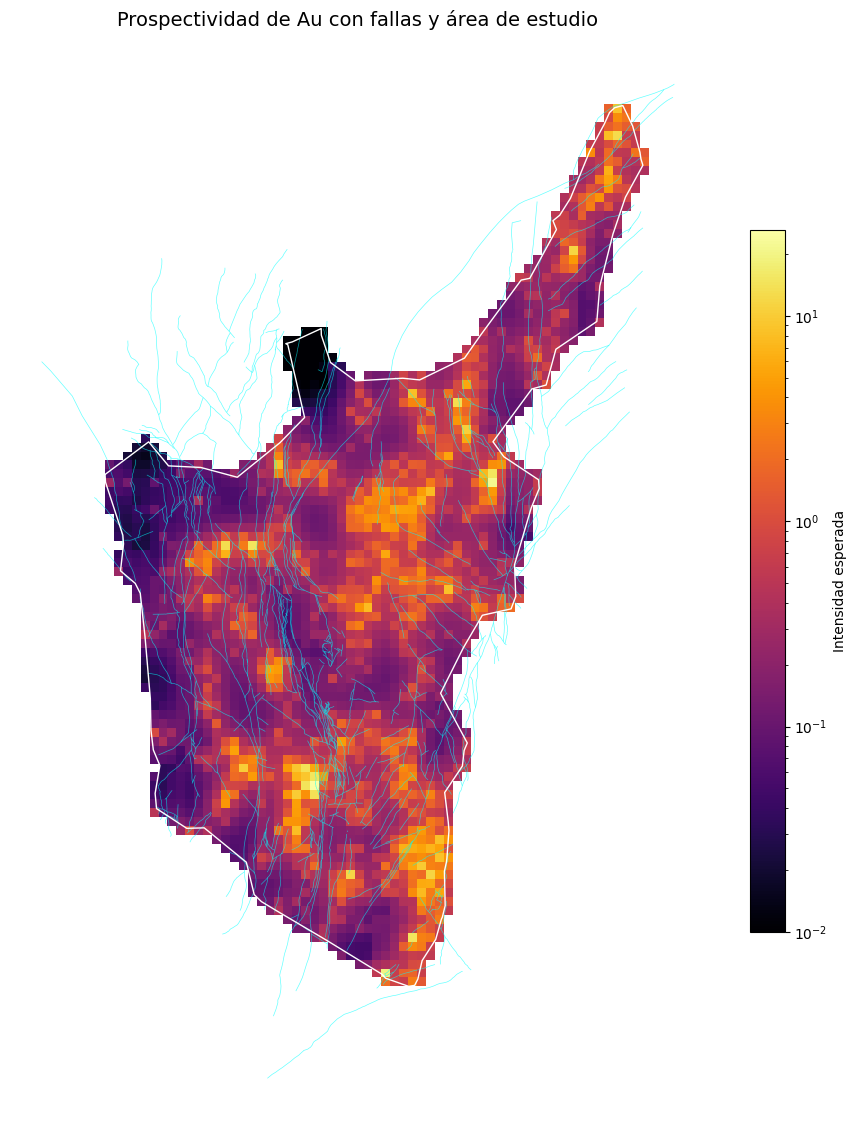

In [50]:
# 3) Mapa enriquecido con fallas y contorno del área
fig, ax = plt.subplots(figsize=(9, 12))

# Capa base: prospectividad
malla.plot(column="prospectividad", cmap="inferno",
           norm=LogNorm(vmin=max(malla["prospectividad"].min(), 0.01),
                        vmax=malla["prospectividad"].max()),
           legend=True, legend_kwds={"label": "Intensidad esperada", "shrink": 0.6},
           ax=ax, edgecolor="none", zorder=1)

# Superponer las fallas (usa tu GeoDataFrame Fallas; reproyecta si hace falta)
Fallas.to_crs(malla.crs).plot(ax=ax, color="cyan", linewidth=0.5, alpha=0.6, zorder=2)

# Contorno del área de trabajo
AreaTrabajo.to_crs(malla.crs).boundary.plot(ax=ax, color="white", linewidth=1, zorder=3)

ax.set_title("Prospectividad de Au con fallas y área de estudio", fontsize=14)
ax.set_aspect("equal"); ax.set_axis_off()
plt.tight_layout()
plt.savefig("MapaProspectividad_contexto.png", dpi=300, bbox_inches="tight")
plt.show()

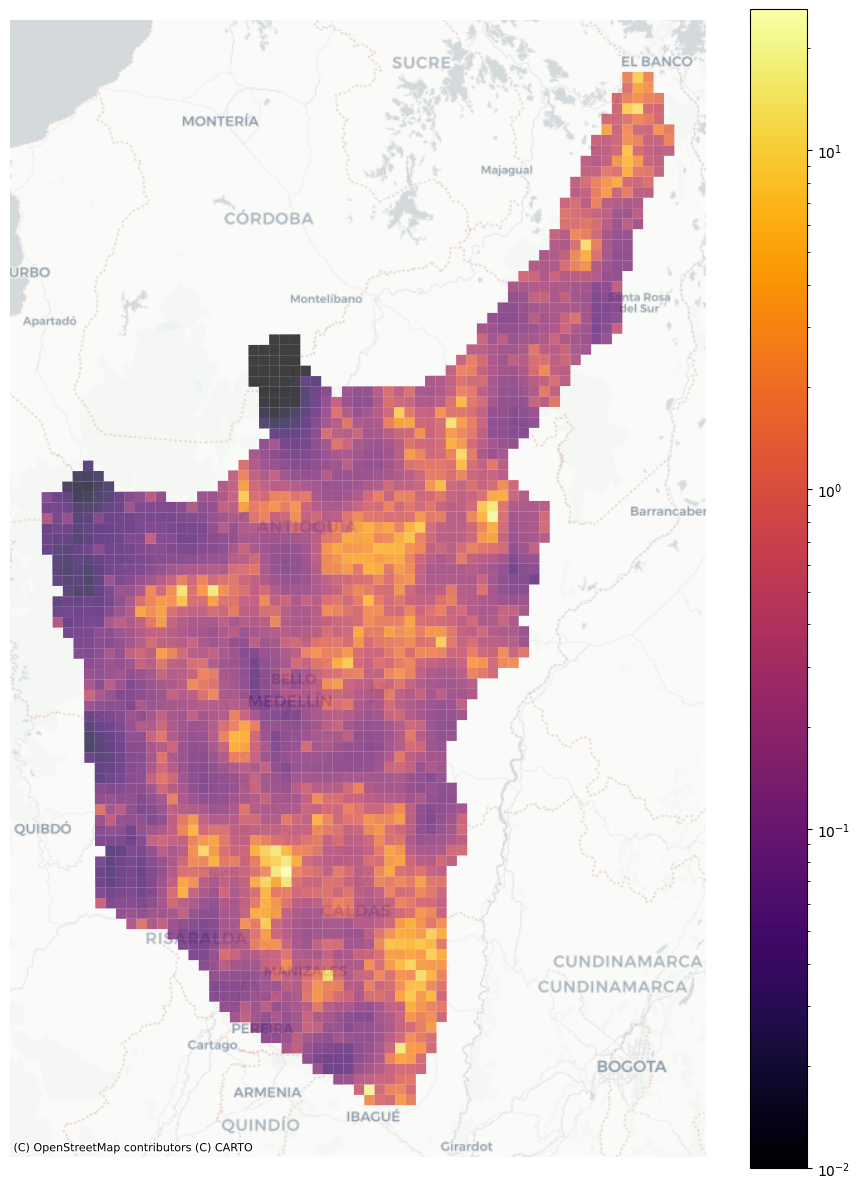

In [51]:
# pip install contextily
import contextily as cx

malla_web = malla.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(9, 12))
malla_web.plot(column="prospectividad", cmap="inferno",
               norm=LogNorm(vmin=max(malla["prospectividad"].min(), 0.01),
                            vmax=malla["prospectividad"].max()),
               legend=True, ax=ax, edgecolor="none", alpha=0.75)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)  # mapa base tenue
ax.set_axis_off()
plt.tight_layout(); plt.show()

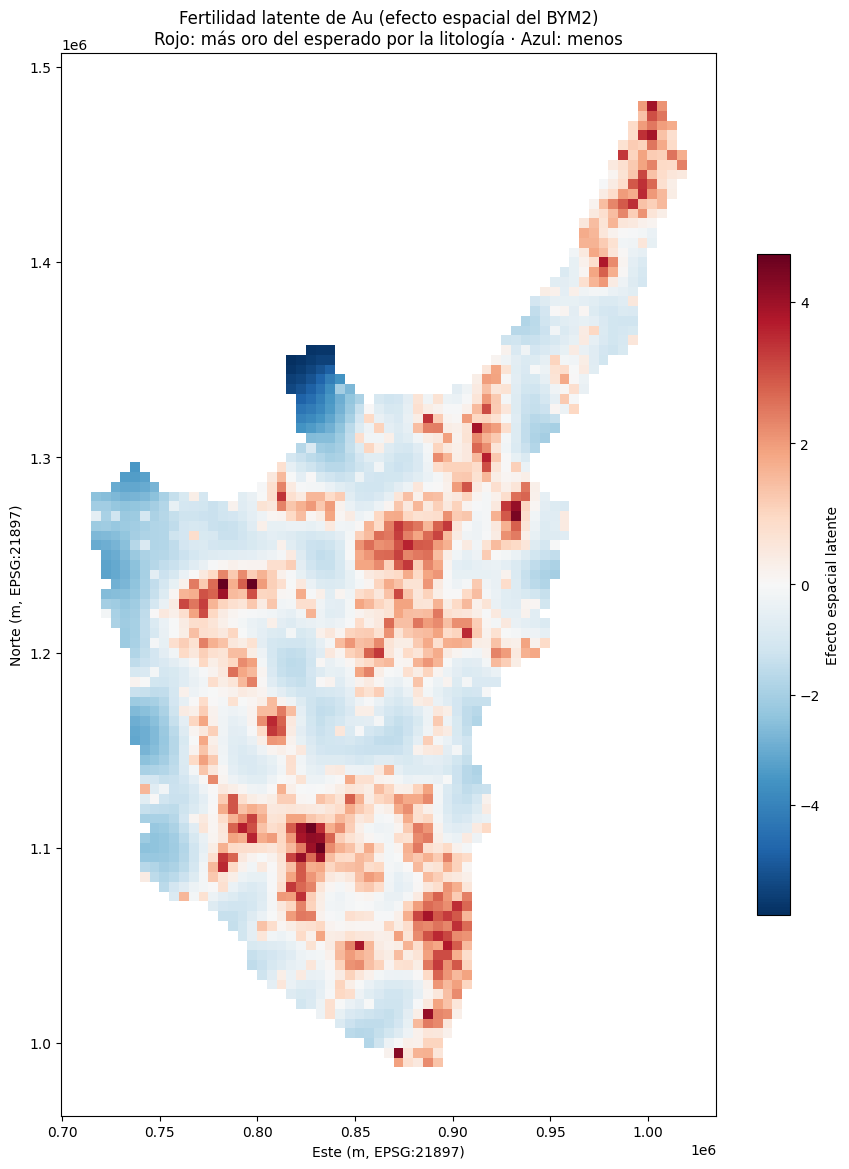

In [52]:
from matplotlib.colors import TwoSlopeNorm

malla = gpd.read_file(r"C:\Users\USUARIO\Documents\ESPECIALIZACION_GNM\ANALISIS_GEOESPACIAL\AnalisisGeoespacial_2026\reticula_bym_resultados.gpkg")

fig, ax = plt.subplots(figsize=(9, 12))

# Norma divergente: azul (negativo) - blanco (0) - rojo (positivo), centrada en 0
norma = TwoSlopeNorm(vmin=malla["efecto_espacial"].min(),
                     vcenter=0,
                     vmax=malla["efecto_espacial"].max())

malla.plot(column="efecto_espacial", cmap="RdBu_r", norm=norma,
           legend=True, legend_kwds={"label": "Efecto espacial latente", "shrink": 0.6},
           ax=ax, edgecolor="none")

ax.set_title("Fertilidad latente de Au (efecto espacial del BYM2)\n"
             "Rojo: más oro del esperado por la litología · Azul: menos", fontsize=12)
ax.set_xlabel("Este (m, EPSG:21897)"); ax.set_ylabel("Norte (m, EPSG:21897)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("FertilidadLatente_python.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
AreaTrabajo.to_file("area_trabajo.gpkg", driver="GPKG")
print("Área exportada. CRS:", AreaTrabajo.crs, "| Tipo:", AreaTrabajo.geom_type.values)

Área exportada. CRS: EPSG:21897 | Tipo: <StringArray>
['Polygon']
Length: 1, dtype: str


In [56]:
OcurrenciasAu.to_file("puntos_au.gpkg", driver="GPKG")
print("Puntos:", len(OcurrenciasAu), "| CRS:", OcurrenciasAu.crs, "| Tipo:", OcurrenciasAu.geom_type.unique())

Puntos: 1835 | CRS: EPSG:21897 | Tipo: <StringArray>
['Point']
Length: 1, dtype: str


In [57]:
# Revisar qué objetos tienen 'lito_grupo' y a qué geometría están asociados
for nombre, obj in list(globals().items()):
    if hasattr(obj, "columns") and "lito_grupo" in getattr(obj, "columns", []):
        try:
            geom_tipo = obj.geom_type.unique()
            print(f"'{nombre}': tiene lito_grupo | geometría = {geom_tipo} | filas = {len(obj)}")
        except Exception:
            print(f"'{nombre}': tiene lito_grupo | (sin geometría clara) | filas = {len(obj)}")
            

'Reticula': tiene lito_grupo | geometría = <StringArray>
['Polygon']
Length: 1, dtype: str | filas = 2548
'malla': tiene lito_grupo | geometría = <StringArray>
['Polygon']
Length: 1, dtype: str | filas = 2548
'malla_web': tiene lito_grupo | geometría = <StringArray>
['Polygon']
Length: 1, dtype: str | filas = 2548


In [58]:
# En Python - exportar la retícula con su litología para el LGCP
Reticula[["lito_grupo", "geometry"]].to_file("reticula_lito.gpkg", driver="GPKG")
print("Exportado. Clases:")
print(Reticula["lito_grupo"].value_counts())

Exportado. Clases:
lito_grupo
Intrusiva             769
Metamorfica           766
Volcanica             448
Mafico_Ultramafica    379
Sed_Cobertura         186
Name: count, dtype: int64
